In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "facebook/opt-125m"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

print(model)

c:\Users\DMLab\anaconda3\envs\yunjun0914\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\DMLab\anaconda3\envs\yunjun0914\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\DMLab\anaconda3\envs\yunjun0914\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\DMLab\anaconda3\envs\yunjun0914\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by defaul

OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 768, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 768)
      (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (layers): ModuleList(
        (0-11): 12 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_layer_norm): LayerNorm((768,), ep

In [3]:
cfg = model.config

print("model_type:", cfg.model_type)
print("hidden_size:", cfg.hidden_size)
print("num_hidden_layers:", cfg.num_hidden_layers)
print("num_attention_heads:", cfg.num_attention_heads)
print("ffn_dim:", cfg.ffn_dim)
print("vocab_size:", cfg.vocab_size)
print("max_position_embeddings:", cfg.max_position_embeddings)

model_type: opt
hidden_size: 768
num_hidden_layers: 12
num_attention_heads: 12
ffn_dim: 3072
vocab_size: 50272
max_position_embeddings: 2048


In [4]:
from datasets import load_dataset

ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

print(ds)
print(ds["train"][0])
print(ds["train"][1])
print(ds["train"][2])

c:\Users\DMLab\anaconda3\envs\yunjun0914\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DMLab\.cache\huggingface\hub\datasets--Salesforce--wikitext. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 1856673.30 examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
{'text': ''}
{'text': ' = Valkyria Chronicles III = \n'}
{'text': ''}


In [36]:
ds.shape

{'test': (4358, 1), 'train': (36718, 1), 'validation': (3760, 1)}

In [16]:
train_texts = [
    x["text"] for x in ds["train"]
    if len(x["text"].strip()) > 0
]

print("num non-empty texts:", len(train_texts))

for i in range(5):
    print("=" * 80)
    print(train_texts[i])

num non-empty texts: 23767
 = Valkyria Chronicles III = 

 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . 

 The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game m

In [17]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "facebook/opt-125m"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

texts = train_texts[:8]

batch = tokenizer(
    texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128,
)

batch = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad():
    out = model(**batch)

print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("logits:", out.logits.shape)

c:\Users\DMLab\anaconda3\envs\yunjun0914\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


input_ids: torch.Size([8, 128])
attention_mask: torch.Size([8, 128])
logits: torch.Size([8, 128, 50272])


In [19]:
for name, param in model.named_parameters():
    print(name, tuple(param.shape))

model.decoder.embed_tokens.weight (50272, 768)
model.decoder.embed_positions.weight (2050, 768)
model.decoder.final_layer_norm.weight (768,)
model.decoder.final_layer_norm.bias (768,)
model.decoder.layers.0.self_attn.k_proj.weight (768, 768)
model.decoder.layers.0.self_attn.k_proj.bias (768,)
model.decoder.layers.0.self_attn.v_proj.weight (768, 768)
model.decoder.layers.0.self_attn.v_proj.bias (768,)
model.decoder.layers.0.self_attn.q_proj.weight (768, 768)
model.decoder.layers.0.self_attn.q_proj.bias (768,)
model.decoder.layers.0.self_attn.out_proj.weight (768, 768)
model.decoder.layers.0.self_attn.out_proj.bias (768,)
model.decoder.layers.0.self_attn_layer_norm.weight (768,)
model.decoder.layers.0.self_attn_layer_norm.bias (768,)
model.decoder.layers.0.fc1.weight (3072, 768)
model.decoder.layers.0.fc1.bias (3072,)
model.decoder.layers.0.fc2.weight (768, 3072)
model.decoder.layers.0.fc2.bias (768,)
model.decoder.layers.0.final_layer_norm.weight (768,)
model.decoder.layers.0.final_laye

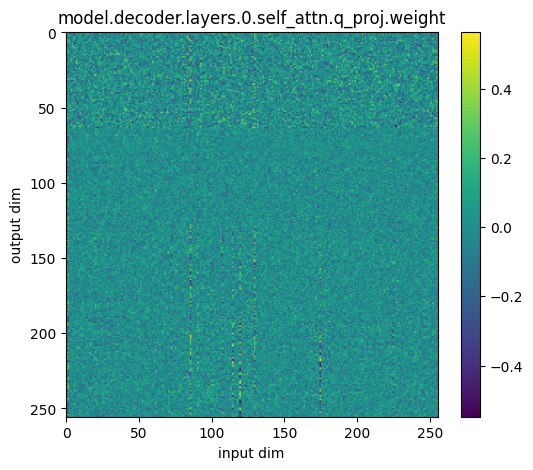

In [21]:
def plot_weight_matrix(model, name, max_rows=256, max_cols=256):
    w = dict(model.named_parameters())[name].detach().float().cpu()
    w = w[:max_rows, :max_cols]

    plt.figure(figsize=(6, 5))
    plt.imshow(w.numpy(), aspect="auto")
    plt.colorbar()
    plt.title(name)
    plt.xlabel("input dim")
    plt.ylabel("output dim")
    plt.show()

plot_weight_matrix(model, "model.decoder.layers.0.self_attn.q_proj.weight")

c:\Users\DMLab\anaconda3\envs\yunjun0914\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


activation shape: torch.Size([128, 128, 768])


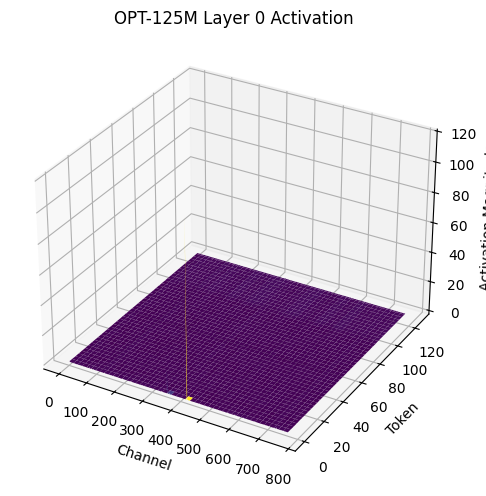

In [133]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

# 1. 모델 / 데이터
model_name = "facebook/opt-125m"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
texts = [x["text"] for x in ds["train"] if x["text"].strip() != ""]

# 2. WikiText2 batch 만들기
batch = tokenizer(
    texts[:128],
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128,
)

batch = {k: v.to(device) for k, v in batch.items()}

# 3. OPT forward 하면서 hidden state activation 받기
with torch.no_grad():
    outputs = model(
        **batch,
        output_hidden_states=True,
    )

# hidden_states[0] = embedding output
# hidden_states[1] = layer 0 output
# hidden_states[2] = layer 1 output
# ...
# hidden_states[12] = layer 11 output
act = outputs.hidden_states[1].detach().float().cpu()

print("activation shape:", act.shape)
# 정상 출력 예: torch.Size([8, 128, 768])

# 4. 네가 올린 사진처럼 3D activation plot
sample_idx = 127

A = act[sample_idx]   # [seq_len, channel]
A = A.abs()           # outlier magnitude
Z = A.numpy()

seq_len, num_channels = Z.shape

X, Y = np.meshgrid(
    np.arange(num_channels),
    np.arange(seq_len),
)

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
)

ax.set_xlabel("Channel")
ax.set_ylabel("Token")
ax.set_zlabel("Activation Magnitude")
ax.set_title("OPT-125M Layer 0 Activation")

plt.tight_layout()
plt.show()

In [134]:
# 보고 싶은 중간 module 이름
target_layer = "model.decoder.layers.0.self_attn.v_proj"
# 예:
# # Embedding 쪽
# "model.decoder.embed_tokens"
# "model.decoder.embed_positions"
# "model.decoder.project_out"
# "model.decoder.project_in"
# "model.decoder.final_layer_norm"

# # Layer 0 전체
# "model.decoder.layers.0"

# # Layer 0 Attention 쪽
# "model.decoder.layers.0.self_attn"
# "model.decoder.layers.0.self_attn.k_proj"
# "model.decoder.layers.0.self_attn.v_proj"
# "model.decoder.layers.0.self_attn.q_proj"
# "model.decoder.layers.0.self_attn.out_proj"

# # Layer 0 LayerNorm 쪽
# "model.decoder.layers.0.self_attn_layer_norm"
# "model.decoder.layers.0.final_layer_norm"

# # Layer 0 FFN 쪽
# "model.decoder.layers.0.fc1"
# "model.decoder.layers.0.fc2"
# "model.decoder.layers.0.activation_fn"


acts = {}

def hook_fn(module, inputs, output):
    acts["input"] = inputs[0].detach().float().cpu()   # X
    acts["output"] = output.detach().float().cpu()     # XW^T + b

for name, module in model.named_modules():
    if name == target_layer:
        handle = module.register_forward_hook(hook_fn)
        break
else:
    raise ValueError(f"Cannot find layer: {target_layer}")

with torch.no_grad():
    _ = model(**batch)

handle.remove()

print("input shape :", acts["input"].shape)
print("output shape:", acts["output"].shape)

input shape : torch.Size([128, 128, 768])
output shape: torch.Size([128, 128, 768])


In [135]:
acts["input"].shape

torch.Size([128, 128, 768])

In [136]:
# Linear에 들어가는 activation X
act = acts["input"]

# Linear를 지난 결과 XW^T + b
# act = acts["output"]

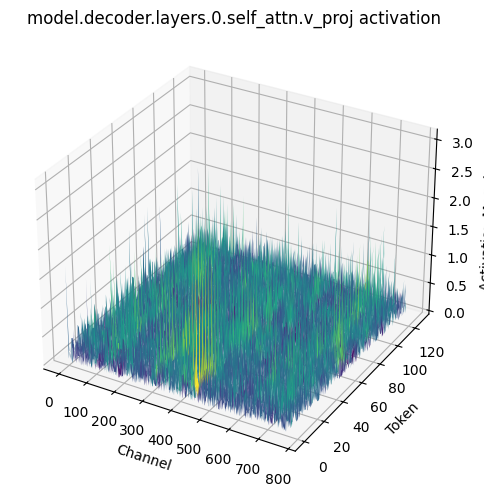

In [137]:
sample_idx = 1

A = act[sample_idx]   # [seq_len, channel]
A = A.abs()
Z = A.numpy()

seq_len, num_channels = Z.shape

X, Y = np.meshgrid(
    np.arange(num_channels),
    np.arange(seq_len),
)

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
)

ax.set_xlabel("Channel")
ax.set_ylabel("Token")
ax.set_zlabel("Activation Magnitude")
ax.set_title(f"{target_layer} activation")

plt.tight_layout()
plt.show()

In [99]:
Z.shape

(3072,)